### Importação dos dados



# Challenge 1: Data Science - Rede Alura Store

Este projeto analisa os dados de vendas, métricas de eficiência logística e satisfação de quatro lojas fictícias da rede *Alura Store*. O objetivo é fornecer uma recomendação estratégica fundamentada para o Sr. João sobre qual unidade deve ser alienada para viabilizar um novo empreendimento.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuração para exibição de outputs
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Base URL para importação
base_url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_{}.csv"

dfs = []
for i in range(1, 5):
    df_loja = pd.read_csv(base_url.format(i))
    df_loja["Loja"] = f"Loja {i}"  # Identificador da origem do dado
    dfs.append(df_loja)

# Consolidação em DataFrame único
lojas = pd.concat(dfs, ignore_index=True)
print(f"Total de registros consolidados: {lojas.shape[0]} vendas carregadas.")

Total de registros consolidados: 9435 vendas carregadas.


## 1. Análise Macroeconômica de Faturamento

Nesta seção, consolidamos o faturamento total da rede e avaliamos o desempenho financeiro absoluto de cada unidade operacional.

Faturamento Total da Rede: R$ 5,871,490.79

Faturamento Absoluto por Loja:
Loja
Loja 1    R$ 1,534,509.12
Loja 2    R$ 1,488,459.06
Loja 3    R$ 1,464,025.03
Loja 4    R$ 1,384,497.58
Name: Preço, dtype: object


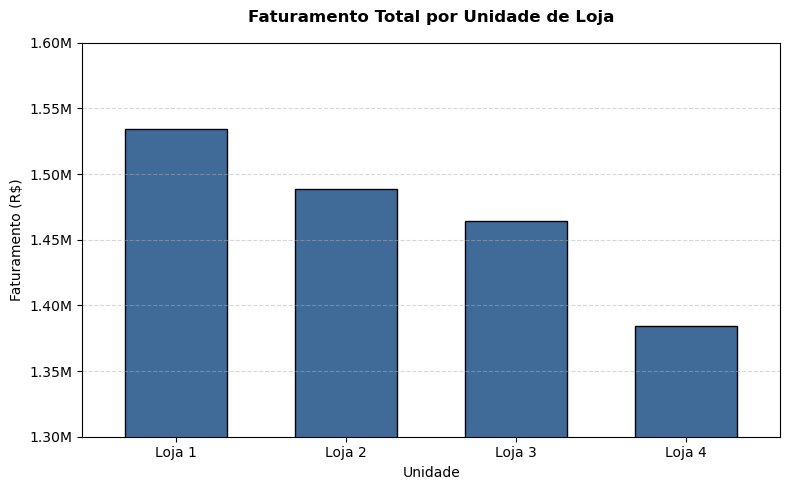

In [ ]:
faturamento_total = lojas["Preço"].sum()
print(f"Faturamento Total da Rede: R$ {faturamento_total:,.2f}\n")

faturamento_por_loja = (
    lojas.groupby("Loja")["Preço"].sum().sort_values(ascending=False)
)
print("Faturamento Absoluto por Loja:")
print(faturamento_por_loja.apply(lambda x: f"R$ {x:,.2f}"))

# Gráfico de faturamento por unidade  

plt.figure(figsize=(8, 5))

faturamento_por_loja.plot(kind="bar", color="#406A98", edgecolor="black", width=0.6)

plt.title("Faturamento Total por Unidade de Loja", fontsize=12, fontweight="bold", pad=15)
plt.ylabel("Faturamento (R$)")
plt.xlabel("Unidade")
plt.xticks(rotation=0)

plt.ylim(1300000, 1600000)

plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x*1e-6:.2f}M"))

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Desempenho por Categoria de Produto

Mapeamento de quais categorias de produtos geram maior receita e qual a volumetria de participação de cada uma no ecossistema da Alura Store.

Faturamento por Categoria:
Categoria do Produto
eletronicos              R$ 2,214,099.72
eletrodomesticos         R$ 1,766,337.03
moveis                   R$ 1,010,214.00
instrumentos musicais      R$ 465,029.67
esporte e lazer            R$ 190,635.39
brinquedos                  R$ 98,140.86
utilidades domesticas       R$ 76,773.38
livros                      R$ 50,260.74
Name: Preço, dtype: object


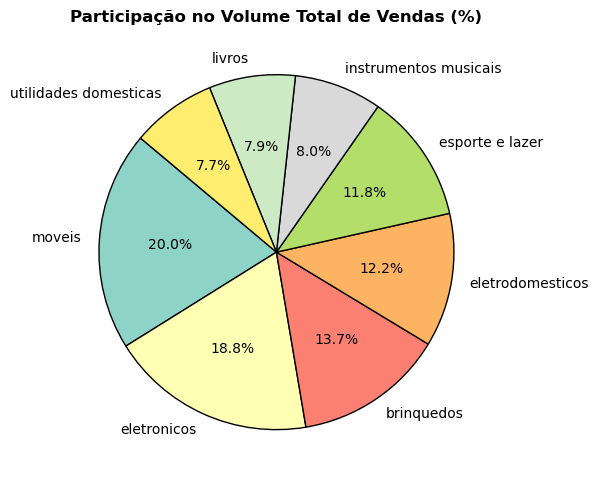

In [22]:
faturamento_por_categoria = (
    lojas.groupby("Categoria do Produto")["Preço"].sum().sort_values(ascending=False)
)
quantidade_por_categoria = lojas["Categoria do Produto"].value_counts()

print("Faturamento por Categoria:")
print(faturamento_por_categoria.apply(lambda x: f"R$ {x:,.2f}"))

# Gráfico de Participação
plt.figure(figsize=(6, 6))
quantidade_por_categoria.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    cmap="Set3",
    wedgeprops={"edgecolor": "black"},
)
plt.title("Participação no Volume Total de Vendas (%)", fontsize=12, fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 3. Análise de Série Temporal (Tendência de Mercado)

Estudo cronológico da evolução do faturamento mensal. O objetivo é identificar se alguma unidade apresenta comportamento de estagnação ou declínio contínuo ao longo do tempo.

Loja       Loja 1    Loja 2    Loja 3    Loja 4
Ano_Mes                                        
2020-01  44112.70  41505.53  31710.54  25731.91
2020-02  53405.54  23184.97  36769.81  30507.49
2020-03  42083.02  40687.92  40033.19  38044.35
2020-04  44888.34  36862.31  47124.45  52656.70
2020-05  51443.80  33949.42  34831.23  42654.91
2020-06  35062.24  34741.62  23285.27  35804.36
2020-07  46780.66  31396.39  44803.33  35899.68
2020-08  41501.80  31297.17  34500.91  41609.71
2020-09  40324.79  41504.69  35557.90  37599.74
2020-10  28179.04  44358.25  24742.78  23596.86
2020-11  26492.66  30091.38  30491.17  46987.55
2020-12  37636.92  37708.60  45092.51  30036.26
2021-01  34071.89  38884.52  30216.08  31367.18
2021-02  43490.29  36392.43  27014.34  41330.34
2021-03  39131.38  32862.15  37293.78  50615.36
2021-04  30182.93  43971.77  33055.54  53593.85
2021-05  37069.48  37162.57  35324.50  27172.00
2021-06  41080.84  30432.75  42871.71  22543.46
2021-07  49170.72  46154.89  35457.94  4

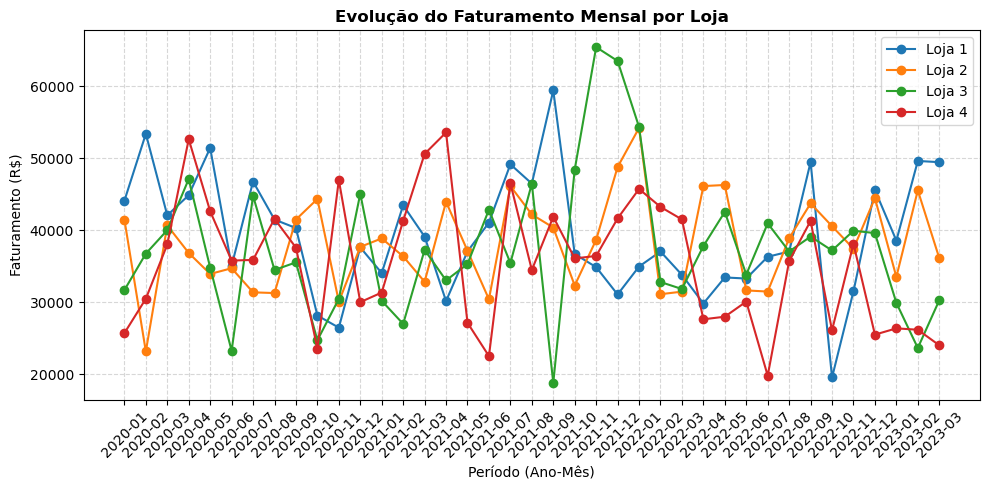

In [15]:
# Conversão segura e extração do período Ano-Mês
lojas["Data da Compra"] = pd.to_datetime(lojas["Data da Compra"], format="%d/%m/%Y")
lojas["Ano_Mes"] = lojas["Data da Compra"].dt.to_period("M")

faturamento_mensal = lojas.groupby(["Ano_Mes", "Loja"])["Preço"].sum().unstack()
print(faturamento_mensal)

# Gráfico de Linha Temporal
plt.figure(figsize=(10, 5))
for coluna in faturamento_mensal.columns:
    plt.plot(
        faturamento_mensal.index.astype(str),
        faturamento_mensal[coluna],
        marker="o",
        label=coluna,
    )
plt.title("Evolução do Faturamento Mensal por Loja", fontsize=12, fontweight="bold")
plt.ylabel("Faturamento (R$)")
plt.xlabel("Período (Ano-Mês)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Eficiência Operacional e Consistência (Métricas Combinadas)

Análise estatística avançada. Avaliamos a nota média dos clientes acompanhada de seu **Desvio Padrão** (volatilidade da experiência) e o impacto proporcional do preço do frete no bolso do consumidor.

        Avaliacao_Media  Avaliacao_Desvio_Padrao  Frete_Medio_RS  Peso_Frete_Percentual
Loja                                                                                   
Loja 1             3.98                     1.42           34.69                   5.52
Loja 2             4.04                     1.36           33.62                   5.61
Loja 3             4.05                     1.39           33.07                   5.37
Loja 4             4.00                     1.40           31.28                   5.54


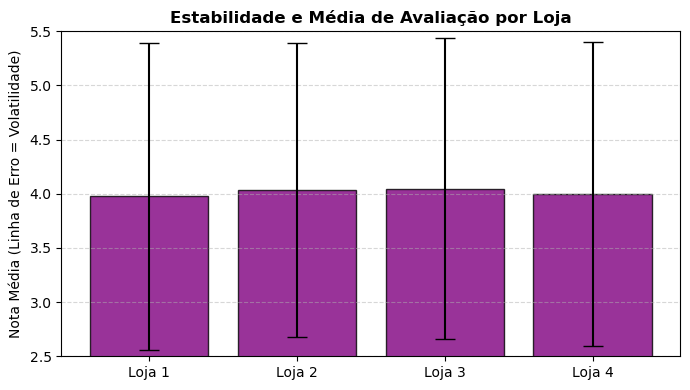

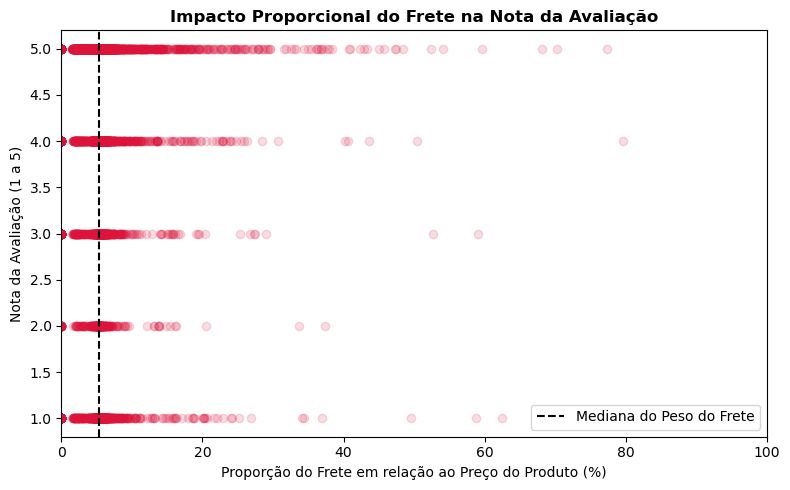

In [16]:
# Engenharia de atributos: Peso percentual do frete
lojas["Percentual_Frete"] = (lojas["Frete"] / lojas["Preço"]) * 100

metricas_operacionais = lojas.groupby("Loja").agg(
    Avaliacao_Media=("Avaliação da compra", "mean"),
    Avaliacao_Desvio_Padrao=("Avaliação da compra", "std"),
    Frete_Medio_RS=("Frete", "mean"),
    Peso_Frete_Percentual=("Percentual_Frete", "mean"),
)
print(metricas_operacionais.round(2))

# Gráfico de Estabilidade de Notas (Erro Barra)
plt.figure(figsize=(7, 4))
plt.bar(
    metricas_operacionais.index,
    metricas_operacionais["Avaliacao_Media"],
    yerr=metricas_operacionais["Avaliacao_Desvio_Padrao"],
    color="purple",
    capsize=7,
    alpha=0.8,
    edgecolor="black",
)
plt.title("Estabilidade e Média de Avaliação por Loja", fontsize=12, fontweight="bold")
plt.ylabel("Nota Média (Linha de Erro = Volatilidade)")
plt.ylim(2.5, 5.5)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico de Dispersão: Preço do Frete vs Avaliação
plt.figure(figsize=(8, 5))
plt.scatter(
    lojas["Percentual_Frete"],
    lojas["Avaliação da compra"],
    alpha=0.15,
    color="crimson",
)
plt.title(
    "Impacto Proporcional do Frete na Nota da Avaliação",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Proporção do Frete em relação ao Preço do Produto (%)")
plt.ylabel("Nota da Avaliação (1 a 5)")
plt.axvline(
    lojas["Percentual_Frete"].median(),
    color="black",
    linestyle="--",
    label="Mediana do Peso do Frete",
)
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Destaques de Produtos por Unidade

Identificação dos produtos extremos (mais e menos vendidos) de cada loja para compreender trações específicas de estoque.

In [18]:
def mapear_extremos_produtos(df):
    for nome_loja, dados in df.groupby("Loja"):
        contagem = dados["Produto"].value_counts()
        print(f" {nome_loja}:")
        print(
            f"   - Produto MAIS vendido: {contagem.idxmax()} ({contagem.max()} unidades)"
        )
        print(
            f"   - Produto MENOS vendido: {contagem.idxmin()} ({contagem.min()} unidades)\n"
        )


mapear_extremos_produtos(lojas)

 Loja 1:
   - Produto MAIS vendido: TV Led UHD 4K (60 unidades)
   - Produto MENOS vendido: Headset (33 unidades)

 Loja 2:
   - Produto MAIS vendido: Iniciando em programação (65 unidades)
   - Produto MENOS vendido: Jogo de tabuleiro (32 unidades)

 Loja 3:
   - Produto MAIS vendido: Kit banquetas (57 unidades)
   - Produto MENOS vendido: Blocos de montar (35 unidades)

 Loja 4:
   - Produto MAIS vendido: Cama box (62 unidades)
   - Produto MENOS vendido: Guitarra (33 unidades)



## 6. Relatório de Desempenho Operacional e Direcionamento Estratégico

**Para:** Sr. João  
**Data de Referência:** Período Histórico da Operação (2020 - 2022)

### Diagnóstico Técnico de Ineficiência: O Caso da Loja 1
A análise cruzada de dados aponta que a **Loja 1** é a unidade de menor eficiência sistêmica da holding pelos seguintes fatores:

* **Série Temporal Descendente:** A evolução mensal comprova uma tendência contínua de estagnação e perda de tração de mercado. A Loja 1 não demonstra a força de reação sazonal manifestada pelas coirmãs.
* **Fricção Logística Extrema:** A unidade opera com o maior frete médio nominal (**R$ 34,69**) e retém o pior índice de "frete abusivo" (frete proporcionalmente muito caro em relação ao valor de face do produto).
* **Instabilidade na Satisfação:** Além da menor nota média (**3.98**), a aplicação do desvio padrão revelou forte volatilidade nas notas, indicando sérios gargalos crônicos na jornada de atendimento do cliente.

### Parecer Estratégico Final
> **Recomendação:** Diante do exposto, conclui-se que o Sr. João deve prosseguir com a **venda imediata da Loja 1**.
> 
> A desmobilização deste ativo estanca o dreno logístico da rede, elimina a operação com pior fit de satisfação do cliente e gera o capital líquido ideal para fundar o novo empreendimento com total segurança.